In [2]:
import opendatasets as od

# Загрузим датасет на прямую с kaggle
dataset_url = 'https://www.kaggle.com/competitions/games-rating/overview'
# Upload Kaggle.json file to Colab… (Caution: Do not Share kaggle.json as contains API key of your Kaggle Account)
# {"username":"adele1997","key":"b359174f8c6e8efc9d9869284646ee1e"}

od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: adele1997
Your Kaggle Key: ··········


100%|██████████| 797k/797k [00:00<00:00, 475MB/s]


Extracting archive ./games-rating/games-rating.zip to ./games-rating


In [3]:
import pandas as pd

train = pd.read_csv('/content/games-rating/train_data.csv')
test = pd.read_csv('/content/games-rating/test_data.csv')
sample_submit = pd.read_csv('/content/games-rating/sample_submition.csv')

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  15247 non-null  float64
 1   Name                15257 non-null  object 
 2   Year Published      15256 non-null  float64
 3   Min Players         15257 non-null  int64  
 4   Max Players         15257 non-null  int64  
 5   Play Time           15257 non-null  int64  
 6   Min Age             15257 non-null  int64  
 7   Users Rated         15257 non-null  int64  
 8   Rating Average      15257 non-null  object 
 9   BGG Rank            15257 non-null  int64  
 10  Complexity Average  15257 non-null  object 
 11  Owned Users         15240 non-null  float64
 12  Mechanics           14057 non-null  object 
 13  Domains             7608 non-null   object 
dtypes: float64(3), int64(6), object(5)
memory usage: 1.6+ MB


In [6]:
train

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,"8,79",1,"3,86",68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,"8,66",3,"3,91",28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
2,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,"8,43",4,"3,24",87099.0,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games
3,233078.0,Twilight Imperium: Fourth Edition,2017.0,3,6,480,14,13468,"8,70",5,"4,22",16831.0,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games"
4,291457.0,Gloomhaven: Jaws of the Lion,2020.0,1,4,120,14,8392,"8,87",6,"3,55",21609.0,"Action Queue, Campaign / Battle Card Driven, C...","Strategy Games, Thematic Games"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15252,1410.0,Trouble,1965.0,2,4,45,4,3255,"3,79",20339,"1,05",4962.0,Roll / Spin and Move,Children's Games
15253,16398.0,War,0.0,2,2,30,4,1340,"2,28",20340,1,427.0,NaN,Children's Games
15254,5048.0,Candy Land,1949.0,2,4,30,3,4006,"3,18",20342,"1,08",5788.0,Roll / Spin and Move,Children's Games
15255,5432.0,Chutes and Ladders,-200.0,2,6,30,3,3783,"2,86",20343,"1,02",4400.0,"Dice Rolling, Grid Movement, Race, Roll / Spin...",Children's Games


In [5]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5086 entries, 0 to 5085
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5080 non-null   float64
 1   Name                5086 non-null   object 
 2   Year Published      5086 non-null   float64
 3   Min Players         5086 non-null   int64  
 4   Max Players         5086 non-null   int64  
 5   Play Time           5086 non-null   int64  
 6   Min Age             5086 non-null   int64  
 7   Users Rated         5086 non-null   int64  
 8   BGG Rank            5086 non-null   int64  
 9   Complexity Average  5086 non-null   object 
 10  Owned Users         5080 non-null   float64
 11  Mechanics           4688 non-null   object 
 12  Domains             2576 non-null   object 
dtypes: float64(3), int64(6), object(4)
memory usage: 516.7+ KB


In [7]:
train['Rating Average'] = (
    train['Rating Average']
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [8]:
train['Complexity Average'] = (
    train['Complexity Average']
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15257 entries, 0 to 15256
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  15247 non-null  float64
 1   Name                15257 non-null  object 
 2   Year Published      15256 non-null  float64
 3   Min Players         15257 non-null  int64  
 4   Max Players         15257 non-null  int64  
 5   Play Time           15257 non-null  int64  
 6   Min Age             15257 non-null  int64  
 7   Users Rated         15257 non-null  int64  
 8   Rating Average      15257 non-null  float64
 9   BGG Rank            15257 non-null  int64  
 10  Complexity Average  15257 non-null  float64
 11  Owned Users         15240 non-null  float64
 12  Mechanics           14057 non-null  object 
 13  Domains             7608 non-null   object 
dtypes: float64(5), int64(6), object(3)
memory usage: 1.6+ MB


In [ ]:
train['Game Age'] = 2025 - train['Year Published']

In [ ]:
train['Game Age'].value_counts()

,count
Game Age,
9.0,963
7.0,949
8.0,941
10.0,852
6.0,844
...,...
94.0,1
1625.0,1
151.0,1


In [ ]:
median_age = train['Game Age'].median()
train['Game Age'] = train['Game Age'].fillna(median_age)

In [ ]:
train.drop(columns=['Domains'], inplace=True)
train.dropna(inplace=True)

KeyError: "['Domains'] not found in axis"

In [ ]:
train.head(2)

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Game Age
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,8.79,1,3.86,68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games",8.0
1,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,8.66,3,3.91,28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games,7.0


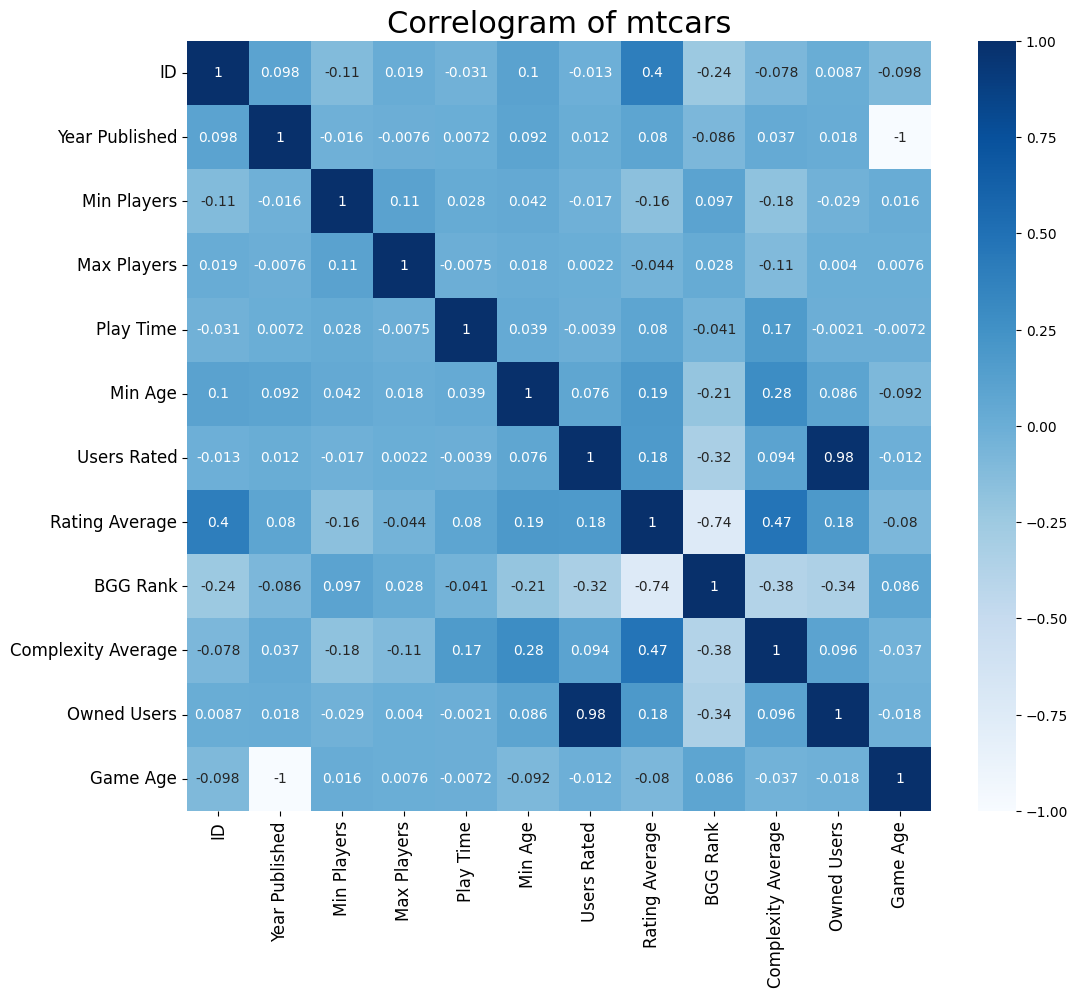

In [ ]:
plt.figure(figsize=(12,10))

corr_matrix = train.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap='Blues', center=0, annot=True)
plt.title('Correlogram of mtcars', fontsize=22)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
corr_matrix

,ID,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Game Age
ID,1.000000,0.097505,-0.114128,0.019475,-0.031008,0.103706,-0.013452,0.399648,-0.236614,-0.078358,0.008744,-0.097505
Year Published,0.097505,1.000000,-0.016228,-0.007565,0.007232,0.091842,0.012105,0.079546,-0.085764,0.036625,0.018334,-1.000000
Min Players,-0.114128,-0.016228,1.000000,0.108232,0.028361,0.042317,-0.016869,-0.158291,0.096783,-0.175218,-0.028768,0.016228
Max Players,0.019475,-0.007565,0.108232,1.000000,-0.007540,0.017650,0.002174,-0.043786,0.028195,-0.105990,0.003990,0.007567
Play Time,-0.031008,0.007232,0.028361,-0.007540,1.000000,0.038525,-0.003893,0.080006,-0.041497,0.168908,-0.002098,-0.007231
Min Age,0.103706,0.091842,0.042317,0.017650,0.038525,1.000000,0.075521,0.187403,-0.210580,0.281572,0.086086,-0.091800
Users Rated,-0.013452,0.012105,-0.016869,0.002174,-0.003893,0.075521,1.000000,0.175867,-0.321523,0.094232,0.984080,-0.012103
Rating Average,0.399648,0.079546,-0.158291,-0.043786,0.080006,0.187403,0.175867,1.000000,-0.737897,0.470200,0.184917,-0.079545
BGG Rank,-0.236614,-0.085764,0.096783,0.028195,-0.041497,-0.210580,-0.321523,-0.737897,1.000000,-0.378614,-0.342471,0.085757
Complexity Average,-0.078358,0.036625,-0.175218,-0.105990,0.168908,0.281572,0.094232,0.470200,-0.378614,1.000000,0.096454,-0.036625


In [ ]:
train.head(2)

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains,Game Age
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,8.79,1,3.86,68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games",8.0
1,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,8.66,3,3.91,28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games,7.0


In [ ]:
X = train.drop(columns=['ID', 'Name', 'Year Published', 'Mechanics','Rating Average'])
Y = train['Rating Average']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Test dataset size: {X_test.shape}, {y_test.shape}')

Train dataset size: (9835, 9), (9835,)
Test dataset size: (4216, 9), (4216,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Создаем модель линейной регрессии - т.е. прямой которая будет проходить через наши точки
# Эта операция создает переменную model в качестве экземпляра LinearRegression

lig_reg = LinearRegression()

# С помощью метода fit() применяем нашу модель к нашему набору данных - обучем модель
# С помощью .fit() вычисляются оптимальные значение весов w₀ и w₁ и т.д,
# используя существующие вход и выход (x и y) в качестве аргументов.

lig_reg.fit(X_train, y_train)

y_pred = lig_reg.predict(X_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R2 score:', r2_score(y_test, y_pred))

Mean Absolute Error: 0.4450721560852581
Mean Squared Error: 0.3703277267945505
R2 score: 0.568113163679559


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

X = train.drop(columns=['ID', 'Name', 'Year Published', 'Mechanics', 'Rating Average'])
y = train['Rating Average']

model = LinearRegression()

# кросс-валидация с 5 фолдами
scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')

print("R2 на каждом фолде:", scores)
print("Среднее R2:", np.mean(scores))

R2 на каждом фолде: [-0.84443159 -0.33459711 -0.5474236  -0.45083778 -1.09492661]
Среднее R2: -0.6544433387255653


In [ ]:
lig_reg = LinearRegression()
lig_reg.fit(X, Y)

LinearRegression()

In [ ]:
test['Complexity Average'] = (test['Complexity Average'].str.replace(',', '.', regex=False).astype(float))

test['Game Age'] = 2025 - test['Year Published']
# median_age = test['Game Age'].median() - так нельзя!
# берем медиану посчитанную на train
test['Game Age'] = test['Game Age'].fillna(median_age)

test.drop(columns=['Domains'], inplace=True)

X_test = test.drop(columns=['ID', 'Name', 'Year Published', 'Mechanics'])

In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5086 entries, 0 to 5085
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Min Players         5086 non-null   int64  
 1   Max Players         5086 non-null   int64  
 2   Play Time           5086 non-null   int64  
 3   Min Age             5086 non-null   int64  
 4   Users Rated         5086 non-null   int64  
 5   BGG Rank            5086 non-null   int64  
 6   Complexity Average  5086 non-null   float64
 7   Owned Users         5086 non-null   float64
 8   Game Age            5086 non-null   float64
dtypes: float64(3), int64(6)
memory usage: 357.7 KB


In [ ]:
median_owned_user = train['Owned Users']
X_test['Owned Users'] = X_test['Owned Users'].fillna(median_owned_user)

In [ ]:
y_test = lig_reg.predict(X_test)

In [ ]:
submition = pd.DataFrame(y_test, columns=['Rating Average'])
submition = submition.reset_index()
submition.to_csv('my_submit_v1.csv', index=False)